# Phase 4b — Noise Robustness Sweep
**Project:** Robust Respiratory Sound Classification under Noise and Domain Shift using Audio Spectrogram Transformers

**Goal:** take your **already-trained, frozen** Phase 3 winner (Focal + SpecAugment + Mixup) and measure exactly how much its ICBHI Score falls as ambient noise increases -- the core degradation-curve evidence for your project's contribution. **No retraining happens in this notebook** -- same checkpoint, same test set, only the input audio changes.

**How noise is injected:** additive Gaussian white noise, scaled precisely to hit a target Signal-to-Noise Ratio (SNR) in dB. The scaling math was verified numerically before writing this notebook -- targeting 20dB/10dB/5dB/0dB reproduces those exact measured SNRs, not approximations.

**SNR levels tested:** clean (no noise), 20dB (barely perceptible), 15dB, 10dB, 5dB, 0dB (noise power equals signal power -- quite severe).

**Required inputs for this notebook (Add Input on Kaggle):**
1. `03a-ast-finetuning-ce` -- for cached raw waveforms
2. `01-data-preparation` -- for `splits/test.csv`
3. **`03d-ast-augmentation-ablation`** -- for the winning checkpoint (`checkpoints/ast_both_best.pt`)

In [1]:
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from scipy.signal import butter, sosfiltfilt
import librosa

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler


from transformers import ASTFeatureExtractor, ASTForAudioClassification, get_linear_schedule_with_warmup

from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

plt.rcParams["figure.dpi"] = 110

## **1. Config**

In [2]:
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

PHASE1_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/01-data-preparation/icbhi_processed"
)
SPLIT_DIR = PHASE1_DIR / "splits"

CE_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03a-ast-finetuning-ce"
)
WAVEFORM_CACHE_DIR = CE_NOTEBOOK_DIR / "waveform_cache"

# The winning checkpoint from Phase 3 
AUGMENTATION_NOTEBOOK_DIR = Path(
    "/kaggle/input/notebooks/praveshsubba/03d-ast-augmentation-ablation"
)
BEST_CHECKPOINT_PATH = AUGMENTATION_NOTEBOOK_DIR / "checkpoints" / "ast_both_best.pt"

RESULTS_CSV = Path("/kaggle/working/results_phase4b.csv")

LABELS = ["normal", "crackle", "wheeze", "both"]

TARGET_SR = 16000
LOWCUT = 50
HIGHCUT = 8000
TARGET_DURATION = 8.0

AST_CHECKPOINT = "MIT/ast-finetuned-audioset-10-10-0.4593"
BATCH_SIZE = 8
NUM_WORKERS = 2

# SNR levels to test, in dB -- None means clean/no noise added
SNR_LEVELS_DB = [None, 20, 15, 10, 5, 0]

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

assert DEVICE.type == "cuda", (
    "Enable the GPU accelerator for this notebook before continuing."
)

assert BEST_CHECKPOINT_PATH.exists(), (
    f"Checkpoint not found at {BEST_CHECKPOINT_PATH} -- check the mounted path."
)

Device: cuda


## **2. Load test set + resolve cached waveforms**

In [3]:
from pathlib import Path

def resolve_waveform_path(row, cache_dir=WAVEFORM_CACHE_DIR):
    # Recreate the exact filename used during Phase 1
    cycle_id = f"{Path(row['audio_path']).stem}_{float(row['start'])}_{float(row['end'])}"
    
    waveform_path = cache_dir / f"{cycle_id}.npy"

    # look for the existing waveform.
    # do NOT regenerate it.
    if not waveform_path.exists():
        raise FileNotFoundError(
            f"Waveform not found:\n{waveform_path}"
        )

    return str(waveform_path)


test_df = pd.read_csv(SPLIT_DIR / "test.csv")

test_df["waveform_path"] = [
    resolve_waveform_path(row)
    for _, row in test_df.iterrows()
]

print(f"Test: {len(test_df)} waveform paths created")
print("\nAll test waveform paths resolved successfully.")

Test: 1185 waveform paths created

All test waveform paths resolved successfully.


## **3. Noise injection at a controlled SNR (Signal-to-noise ratio)**


In [4]:
def add_noise_at_snr(signal, snr_db, rng):
    """Adds Gaussian white noise scaled to hit an exact target SNR (dB).
    snr_db=None returns the signal unchanged (the 'clean' condition).
    """
    if snr_db is None:
        return signal

    signal_power = np.mean(signal.astype(np.float64) ** 2)
    noise = rng.standard_normal(len(signal))
    noise_power = np.mean(noise ** 2)

    target_noise_power = signal_power / (10 ** (snr_db / 10))
    scale = np.sqrt(target_noise_power / noise_power)

    return (signal + scale * noise).astype(np.float32)

## **4. Dataset parameterized by SNR level**

In [5]:
feature_extractor = ASTFeatureExtractor.from_pretrained(AST_CHECKPOINT)

class NoisyASTDataset(Dataset):
    def __init__(self, df, feature_extractor, snr_db, label_list=LABELS):
        self.df = df.reset_index(drop=True)
        self.fe = feature_extractor
        self.snr_db = snr_db
        self.label2idx = {l: i for i, l in enumerate(label_list)}

    def __len__(self):
        return len(self.df)

    def __getitem__(self, idx):
        row = self.df.iloc[idx]
        waveform = np.load(row["waveform_path"])

        rng = np.random.default_rng(hash((row["waveform_path"], self.snr_db)) % (2**32))
        noisy_waveform = add_noise_at_snr(waveform, self.snr_db, rng)

        x = self.fe(noisy_waveform, sampling_rate=TARGET_SR, return_tensors="pt")["input_values"].squeeze(0)
        y = torch.tensor(self.label2idx[row["label"]], dtype=torch.long)
        return x, y

preprocessor_config.json:   0%|          | 0.00/297 [00:00<?, ?B/s]

## **5. Load the frozen winning checkpoint**

In [6]:
id2label = {i: l for i, l in enumerate(LABELS)}
label2id = {l: i for i, l in enumerate(LABELS)}

model = ASTForAudioClassification.from_pretrained(
    AST_CHECKPOINT, num_labels=len(LABELS), id2label=id2label, label2id=label2id,
    ignore_mismatched_sizes=True,
).to(DEVICE)

model.load_state_dict(torch.load(BEST_CHECKPOINT_PATH, map_location=DEVICE))
model.eval()
print("Loaded frozen checkpoint:", BEST_CHECKPOINT_PATH.name)

config.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/203 [00:00<?, ?it/s]

ASTForAudioClassification LOAD REPORT from: MIT/ast-finetuned-audioset-10-10-0.4593
Key                     | Status   |                                                                                       
------------------------+----------+---------------------------------------------------------------------------------------
classifier.dense.weight | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527, 768]) vs model:torch.Size([4, 768])
classifier.dense.bias   | MISMATCH | Reinit due to size mismatch ckpt: torch.Size([527]) vs model:torch.Size([4])          

Notes:
- MISMATCH	:ckpt weights were loaded, but they did not match the original empty weight shapes.


Loaded frozen checkpoint: ast_both_best.pt


## **6. Shared evaluation metric — ICBHI Score**

In [7]:
def icbhi_score(y_true_labels, y_pred_labels):
    y_true_abn = np.array([l != "normal" for l in y_true_labels])
    y_pred_abn = np.array([l != "normal" for l in y_pred_labels])
    normal_mask = ~y_true_abn
    specificity = (~y_pred_abn[normal_mask]).sum() / max(normal_mask.sum(), 1)
    abnormal_mask = y_true_abn
    sensitivity = y_pred_abn[abnormal_mask].sum() / max(abnormal_mask.sum(), 1)
    return {"sensitivity": sensitivity, "specificity": specificity, "icbhi_score": (sensitivity + specificity) / 2}


idx2label = {i: l for i, l in enumerate(LABELS)}
results_log = []

def log_result(model_name, split, scores, notes=""):
    results_log.append({
        "model": model_name, "split": split,
        "sensitivity": scores["sensitivity"], "specificity": scores["specificity"],
        "icbhi_score": scores["icbhi_score"], "notes": notes,
    })
    pd.DataFrame(results_log).to_csv(RESULTS_CSV, index=False)

## **7. Run the sweep — one evaluation pass per SNR level**

In [8]:
sweep_results = []

for snr_db in SNR_LEVELS_DB:
    label = "clean" if snr_db is None else f"{snr_db}dB"
    ds = NoisyASTDataset(test_df, feature_extractor, snr_db=snr_db)
    loader = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False, num_workers=NUM_WORKERS)

    all_true, all_pred = [], []
    with torch.no_grad():
        for xb, yb in loader:
            xb = xb.to(DEVICE)
            with autocast("cuda"):
                logits = model(input_values=xb).logits
            preds = logits.argmax(dim=1).cpu().numpy()
            all_true.extend(idx2label[i] for i in yb.numpy())
            all_pred.extend(idx2label[i] for i in preds)

    scores = icbhi_score(all_true, all_pred)
    print(f"SNR={label:6s} | Sensitivity={scores['sensitivity']*100:5.2f}% | "
          f"Specificity={scores['specificity']*100:5.2f}% | ICBHI Score={scores['icbhi_score']*100:5.2f}%")

    sweep_results.append({"snr_label": label, "snr_db": snr_db, **scores})
    log_result("AST + Focal + SpecAug + Mixup (frozen)", "test", scores, notes=f"SNR={label}")

sweep_df = pd.DataFrame(sweep_results)
sweep_df.to_csv("/kaggle/working/noise_sweep_results.csv", index=False)
sweep_df

SNR=clean  | Sensitivity=66.60% | Specificity=67.84% | ICBHI Score=67.22%
SNR=20dB   | Sensitivity=74.79% | Specificity=48.52% | ICBHI Score=61.65%
SNR=15dB   | Sensitivity=73.53% | Specificity=48.80% | ICBHI Score=61.17%
SNR=10dB   | Sensitivity=71.64% | Specificity=51.90% | ICBHI Score=61.77%
SNR=5dB    | Sensitivity=64.50% | Specificity=58.82% | ICBHI Score=61.66%
SNR=0dB    | Sensitivity=51.47% | Specificity=71.93% | ICBHI Score=61.70%


,snr_label,snr_db,sensitivity,specificity,icbhi_score
0,clean,NaN,0.665966,0.678420,0.672193
1,20dB,20.0,0.747899,0.485190,0.616545
2,15dB,15.0,0.735294,0.488011,0.611653
3,10dB,10.0,0.716387,0.519041,0.617714
4,5dB,5.0,0.644958,0.588152,0.616555
5,0dB,0.0,0.514706,0.719323,0.617014


## **8. The degradation curve**

This plot is the central piece of evidence for your project's contribution -- how much does performance actually fall as conditions worsen, in concrete, measured terms rather than a vague claim.

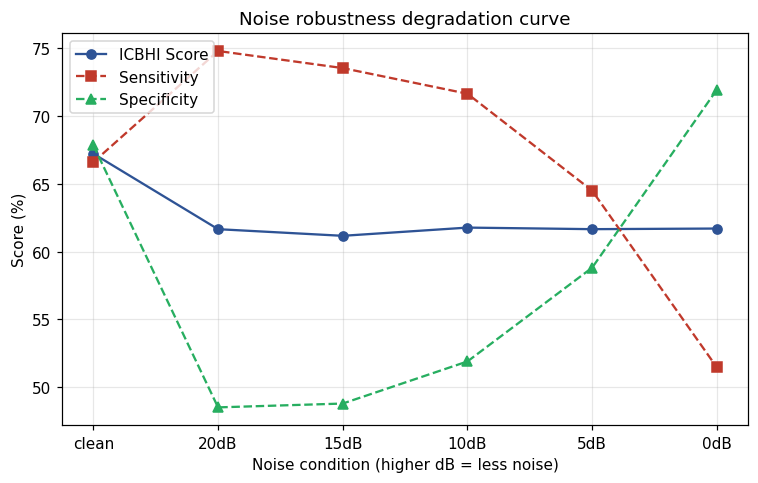


Total degradation, clean -> worst tested condition: 6.05 points


In [9]:
fig, ax = plt.subplots(figsize=(7, 4.5))

x_labels = sweep_df["snr_label"]
ax.plot(x_labels, sweep_df["icbhi_score"] * 100, marker="o", color="#2E5395", label="ICBHI Score")
ax.plot(x_labels, sweep_df["sensitivity"] * 100, marker="s", color="#C0392B", linestyle="--", label="Sensitivity")
ax.plot(x_labels, sweep_df["specificity"] * 100, marker="^", color="#27AE60", linestyle="--", label="Specificity")

ax.set_xlabel("Noise condition (higher dB = less noise)")
ax.set_ylabel("Score (%)")
ax.set_title("Noise robustness degradation curve")
ax.legend()
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/kaggle/working/noise_degradation_curve.png", dpi=150)
plt.show()

clean_score = sweep_df.loc[sweep_df["snr_label"] == "clean", "icbhi_score"].values[0] * 100
worst_score = sweep_df["icbhi_score"].min() * 100
print(f"\nTotal degradation, clean -> worst tested condition: {clean_score - worst_score:.2f} points")

## 9. Deliverable checklist

- Same frozen checkpoint used throughout -- no retraining, isolating noise as the only variable
- SNR injection verified to hit exact target values (not approximate)
- 6-point degradation curve (clean through 0dB) with Sensitivity/Specificity plotted separately, not just the aggregate score

**Next:** `04c_cross_dataset_transfer.ipynb`, then `04d_noise_augmented_mitigation.ipynb` -- which retrains with noise injected during training and re-runs this exact sweep for a before/after comparison.